-----

In [1]:
# def min_max_normalization(x):
#     return (x - x.min()) / (x.max() - x.min())

# def denormalize(df_norm, orig_min, orig_max):
#     return df_norm * (orig_max - orig_min) + orig_min

# numeric_cols = sampled_data.select_dtypes(include=[np.number])

# orig_min = numeric_cols.min()
# orig_max = numeric_cols.max()

# min_max_data = numeric_cols.apply(min_max_normalization)

# min_max_data  = min_max_data.drop(['int.rate', 'installment', 'log.annual.inc'], axis=1)

# categorical_cols = sampled_data.select_dtypes(exclude=[np.number])
# full_min_max_data = pd.concat([min_max_data, categorical_cols], axis=1)

# min_max_data.head()

In [2]:
# debt_data = full_min_max_data[full_min_max_data['purpose'] == 'debt_consolidation']
# credit_data = full_min_max_data[full_min_max_data['purpose'] == 'credit_card']

In [3]:
# X_train_debt, X_test_debt, y_train_debt, y_test_debt = train_test_split(debt_data.iloc[:, :-3], debt_data['credit.policy'], test_size=0.2, random_state=123)

# X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(credit_data.iloc[:, :-3], credit_data['credit.policy'], test_size=0.2, random_state=123)

In [4]:
# X_debt, y_debt = debt_data.iloc[:, :-3], debt_data['credit.policy']

# X_credit, y_credit = credit_data.iloc[:, :-3], credit_data['credit.policy']

-----

# Bibliotekos

In [5]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn import svm
from sklearn.ensemble import AdaBoostClassifier as AdaBoost
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import SGDClassifier

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

# Duomenys

In [6]:
file_path = os.path.join("..", "1_laboratorinis", "loan_data.csv")
data = pd.read_csv(file_path)

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    data[col] = data[col].astype('category')

data['annual.inc'] = np.exp(data['log.annual.inc'])

print(f"Eilučių skaičius: {len(data)}")
print(f"Stulpelių skaičius: {len(data.columns)}")

Eilučių skaičius: 9578
Stulpelių skaičius: 15


In [7]:
sampled_data = data.groupby(['purpose', 'credit.policy'], observed=False).sample(
    frac=0.6, 
    random_state=6202
).reset_index(drop=True)

print(f"\nAtrinktų duomenų dydis: {len(sampled_data)}")


Atrinktų duomenų dydis: 5746


In [8]:
debt_data = sampled_data[sampled_data['purpose'] == 'debt_consolidation']
debt_data = debt_data.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc'])
debt_data.head()

,credit.policy,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
2156,0,26.40,697,3840.000000,5132,41.4,2,0,0,0,45000.000056
2157,0,13.02,687,2130.000000,9451,33.3,4,0,0,1,37499.999927
2158,0,19.52,672,4529.958333,8443,33.2,4,1,0,0,38000.000049
2159,0,16.19,672,6360.000000,5494,83.2,4,0,0,0,60999.999808
2160,0,26.52,667,2672.958333,21300,65.5,4,0,0,0,55199.999875


In [9]:
credit_data = sampled_data[sampled_data['purpose'] == 'credit_card']
credit_data = credit_data.drop(columns=['purpose', 'int.rate', 'installment', 'log.annual.inc'])
credit_data.head()

,credit.policy,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,annual.inc
1399,0,16.87,677,3779.958333,2488,62.2,5,0,0,0,34999.999983
1400,0,15.14,647,3299.000000,36662,82.9,0,0,0,0,49999.999779
1401,0,4.51,727,600.000000,669,7.0,0,0,0,0,49999.999779
1402,0,6.24,657,2490.000000,8558,80.7,3,0,0,0,71000.000282
1403,0,12.26,702,6960.000000,56200,57.4,4,0,0,0,159999.999325


In [10]:
X_debt = debt_data.drop(['credit.policy', 'not.fully.paid'], axis=1)
y_debt = debt_data['credit.policy']

X_credit = credit_data.drop(['credit.policy', 'not.fully.paid'], axis=1)
y_credit = credit_data['credit.policy']

In [11]:
X_debt.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
2156,26.40,697,3840.000000,5132,41.4,2,0,0,45000.000056
2157,13.02,687,2130.000000,9451,33.3,4,0,0,37499.999927
2158,19.52,672,4529.958333,8443,33.2,4,1,0,38000.000049
2159,16.19,672,6360.000000,5494,83.2,4,0,0,60999.999808
2160,26.52,667,2672.958333,21300,65.5,4,0,0,55199.999875


# Algoritmai su numatytais parametrais

## Kryžminė validacija

In [12]:
cv_strategy = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)

### SVC

In [13]:
svc_pipeline = make_pipeline(MinMaxScaler(), svm.SVC())

scores_svc_debt = cross_val_score(svc_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
print(f"Konsolidavimo: {scores_svc_debt.mean()}")

scores_svc_credit = cross_val_score(svc_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
print(f"Kredito kortelės: {scores_svc_credit.mean()}")

Konsolidavimo: 0.9283506622988178
Kredito kortelės: 0.8837126600284495


### AdaBoost

In [14]:
svc_AdaBoost_pipeline = make_pipeline(MinMaxScaler(), AdaBoost())

scores_AdaBoost_debt = cross_val_score(svc_AdaBoost_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
print(f"Konsolidavimo: {scores_AdaBoost_debt.mean()}")

scores_AdaBoost_credit = cross_val_score(svc_AdaBoost_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
print(f"Kredito kortelės: {scores_AdaBoost_credit.mean()}")

Konsolidavimo: 0.9692173479561313
Kredito kortelės: 0.9446657183499287


### Bernoulli naive bayes

In [15]:
svc_BernoulliNB_pipeline = make_pipeline(MinMaxScaler(), BernoulliNB())

scores_BernoulliNB_debt = cross_val_score(svc_BernoulliNB_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
print(f"Konsolidavimo: {scores_BernoulliNB_debt.mean()}")

scores_BernoulliNB_credit = cross_val_score(svc_BernoulliNB_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
print(f"Kredito kortelės: {scores_BernoulliNB_credit.mean()}")

Konsolidavimo: 0.8150726392251816
Kredito kortelės: 0.805832147937411


### Logistic Regression

In [16]:
svc_lr_pipeline = make_pipeline(MinMaxScaler(), LogisticRegression())

scores_lr_debt = cross_val_score(svc_lr_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
print(f"Konsolidavimo: {scores_lr_debt.mean()}")

scores_lr_credit = cross_val_score(svc_lr_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
print(f"Kredito kortelės: {scores_lr_credit.mean()}")

Konsolidavimo: 0.9089837629967242
Kredito kortelės: 0.8560099573257467


### Gradient Boosting

In [17]:
gb_pipeline = make_pipeline(MinMaxScaler(), GradientBoostingClassifier())

scores_gb_debt = cross_val_score(gb_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
print(f"Konsolidavimo: {scores_gb_debt.mean()}")

scores_gb_credit = cross_val_score(gb_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
print(f"Kredito kortelės: {scores_gb_credit.mean()}")

Konsolidavimo: 0.992412049565589
Kredito kortelės: 0.976280227596017


### Gaussian Naive Bayes

In [18]:
gnb_pipeline = make_pipeline(MinMaxScaler(), GaussianNB())

scores_gnb_debt = cross_val_score(gnb_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
print(f"Konsolidavimo: {scores_gnb_debt.mean()}")

scores_gnb_credit = cross_val_score(gnb_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
print(f"Kredito kortelės: {scores_gnb_credit.mean()}")

Konsolidavimo: 0.8748896168636948
Kredito kortelės: 0.8216571834992887


### Random Forest

In [19]:
rf_pipeline = make_pipeline(MinMaxScaler(), RandomForestClassifier())

scores_rf_debt = cross_val_score(rf_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
print(f"Konsolidavimo: {scores_rf_debt.mean()}")

scores_rf_credit = cross_val_score(rf_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
print(f"Kredito kortelės: {scores_rf_credit.mean()}")

Konsolidavimo: 0.9907242558040166
Kredito kortelės: 0.975


### K-Nearest Neighbors

In [20]:
knn_pipeline = make_pipeline(MinMaxScaler(), KNeighborsClassifier())

scores_knn_debt = cross_val_score(knn_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
print(f"Konsolidavimo: {scores_knn_debt.mean()}")

scores_knn_credit = cross_val_score(knn_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
print(f"Kredito kortelės: {scores_knn_credit.mean()}")

Konsolidavimo: 0.9085778379148269
Kredito kortelės: 0.8639402560455192


### Passive Aggressive

In [21]:
pa_pipeline = make_pipeline(MinMaxScaler(), PassiveAggressiveClassifier())

scores_pa_debt = cross_val_score(pa_pipeline, X_debt, y_debt, cv=cv_strategy, scoring='accuracy')
print(f"Konsolidavimo: {scores_pa_debt.mean()}")

scores_pa_credit = cross_val_score(pa_pipeline, X_credit, y_credit, cv=cv_strategy, scoring='accuracy')
print(f"Kredito kortelės: {scores_pa_credit.mean()}")

c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', pe

Konsolidavimo: 0.8871065375302664
Kredito kortelės: 0.8268136557610241


c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\eveli\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


-----

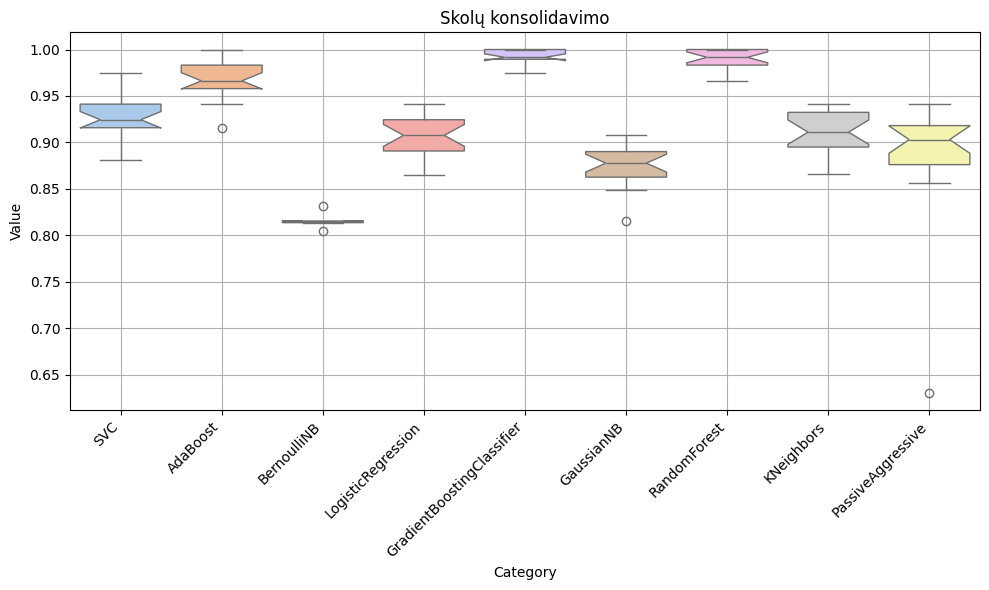

In [22]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20 + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_debt, scores_AdaBoost_debt, scores_BernoulliNB_debt, scores_lr_debt, scores_gb_debt, scores_gnb_debt, scores_rf_debt, scores_knn_debt, scores_pa_debt])
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Skolų konsolidavimo")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

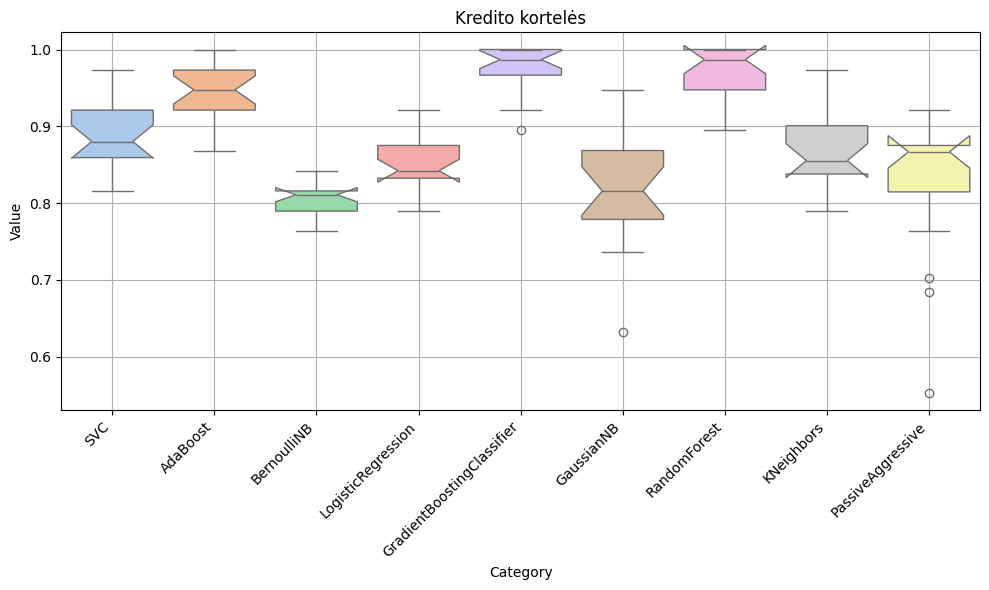

In [23]:
df = pd.DataFrame({
    'Category': ['SVC']*20 + ['AdaBoost']*20 + ['BernoulliNB']*20 + ['LogisticRegression']*20 + ['GradientBoostingClassifier']*20+['GaussianNB']*20  + ['RandomForest']*20 + ['KNeighbors']*20 + ['PassiveAggressive']*20,
    'Value': np.concatenate([scores_svc_credit, scores_AdaBoost_credit, scores_BernoulliNB_credit, scores_lr_credit, scores_gb_credit, scores_gnb_credit, scores_rf_credit, scores_knn_credit, scores_pa_credit])
})


plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Value', data=df, notch=True, palette="pastel", hue='Category')
plt.title("Kredito kortelės")
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()

plt.show()

-----

# Mokymo ir testavimo aibė

In [24]:
X_train_debt, X_test_debt, y_train_debt, y_test_debt = train_test_split(debt_data.drop(columns=['not.fully.paid', 'credit.policy']), debt_data['credit.policy'], test_size=0.2, random_state=123)

X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(credit_data.drop(columns=['not.fully.paid', 'credit.policy']), credit_data['credit.policy'], test_size=0.2, random_state=123)

In [25]:
X_train_debt.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc
3124,3.78,767,3390.000000,3252,13.7,0,0,0,59999.999928
3618,22.55,677,1920.041667,7679,38.8,1,0,0,24000.000016
2803,4.92,682,1350.041667,1737,48.2,1,0,0,14400.000006
3874,16.36,752,3360.000000,12442,33.7,0,0,0,32999.999985
2349,13.81,662,4110.041667,13020,33.0,4,0,0,54999.999768


# Min-Max normalizavimas

In [26]:
min_max_scaler = MinMaxScaler()

X_train_debt_norm = min_max_scaler.fit_transform(X_train_debt)
X_test_debt_norm = min_max_scaler.transform(X_test_debt)

X_train_credit_norm = min_max_scaler.fit_transform(X_train_credit)
X_test_credit_norm = min_max_scaler.transform(X_test_credit)